#Str.contains

In [ ]:
import pandas as pd

#Creamos un dataframe
datos_campanas={
    "ID_Campaña":[1,2,3,4],
    "Nombre_Campaña":["Promo Navidad", "REBAJAS DE VERANO", "Liquidacion total", "Especial rebaja socio"],
    "Retorno_Inversion": [15000, 28000,5000, 12000]
}
df_marketing=pd.DataFrame(datos_campanas)

#Queremos filtar las campañas que tengan las palabras "Rebaja"o "Liquidación"
palabras_clave ="rebaja|liquidacion"

campanas_filtradas=df_marketing[df_marketing["Nombre_Campaña"].str.contains(palabras_clave, case=False, na=False)]

campanas_filtradas

,ID_Campaña,Nombre_Campaña,Retorno_Inversion
1,2,REBAJAS DE VERANO,28000
2,3,Liquidacion total,5000
3,4,Especial rebaja socio,12000


# Función apply

In [ ]:
# Primero tenemos que definir una función
def clasificar_retorno(ingreso):
  if pd.isna(ingreso):
    return "Desconocido"
  elif ingreso>20000:
    return "Alto"
  else:
    return "Normal"

#Ahora aplicamos esta función a cada fila
df_marketing["Categoria_Retorno"]=df_marketing["Retorno_Inversion"].apply(lambda x: clasificar_retorno(x))

df_marketing

,ID_Campaña,Nombre_Campaña,Retorno_Inversion,Categoria_Retorno
0,1,Promo Navidad,15000,Normal
1,2,REBAJAS DE VERANO,28000,Alto
2,3,Liquidacion total,5000,Normal
3,4,Especial rebaja socio,12000,Normal


# One - Hot Encoding

## PAndas

In [ ]:
datos = {
    "id_cliente": [1,2,3],
    "suscripcion": ["Gratis", "Premium", "Basica"]
}
df=pd.DataFrame(datos)
print(df)
#Aplicamos One-Hot Encoding
df_codificado = pd.get_dummies(df,columns=["suscripcion"], dtype=int)
print(df_codificado)

   id_cliente suscripcion
0           1      Gratis
1           2     Premium
2           3      Basica
   id_cliente  suscripcion_Basica  suscripcion_Gratis  suscripcion_Premium
0           1                   0                   1                    0
1           2                   0                   0                    1
2           3                   1                   0                    0


## Scikit - Learn

In [ ]:
from sklearn.preprocessing import OneHotEncoder

datos_historicos = pd.DataFrame({
    'Suscripcion': ['Gratis', 'Premium', 'Basica']
})

# Definimos el objeto
codificador= OneHotEncoder(sparse_output=False)

#Primero entrenamos el "modelo". Aprende las categorias
codificador.fit(datos_historicos[["Suscripcion"]])

#Aplicar lo aprendido
resultado = codificador.fit_transform(datos_historicos[["Suscripcion"]])
#Sale sin columnas
resultado

# En un solo paso: resultado = codificador.fit_transform(datos_historicos[["Suscripcion"]])

#Para ponerle columnas
columnas = codificador.get_feature_names_out(['Suscripcion'])
df_codificado = pd.DataFrame(resultado, columns=columnas)
print(df_codificado)


#Recogemos un dato nuevo
cliente_nuevo = pd.DataFrame ({
    "Suscripcion": ["Premium"]
})
resultado_nuevo = codificador.transform(cliente_nuevo[["Suscripcion"]])
df_nuevo = pd.DataFrame(resultado_nuevo, columns=columnas)
#df_nuevo

   Suscripcion_Basica  Suscripcion_Gratis  Suscripcion_Premium
0                 0.0                 1.0                  0.0
1                 0.0                 0.0                  1.0
2                 1.0                 0.0                  0.0


# Normalizar y estandarizar los datos

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

datos = {
    "Edad": [20, 60, 80],
    "Sueldo": [15000, 40000, 1000000]
}
df=pd.DataFrame(datos)

#Llamamos a la herramienta
scaler = MinMaxScaler()
scaler2 = StandardScaler()

df[["Edad_Escalada", "Sueldo_Escalado"]] = scaler.fit_transform(df[["Edad", "Sueldo"]])

df[["Edad_std", "Sueldo_std"]] = scaler2.fit_transform(df[["Edad", "Sueldo"]])

df

,Edad,Sueldo,Edad_Escalada,Sueldo_Escalado,Edad_std,Sueldo_std
0,20,15000,0.000000,0.000000,-1.336306,-0.734191
1,60,40000,0.666667,0.025381,0.267261,-0.679672
2,80,1000000,1.000000,1.000000,1.069045,1.413863


¿Que pasaría si añadieramos una edad fuera del rango y usaramos directamente el transform?

In [ ]:
nuevo = pd.DataFrame({
    "Edad": [10],
    "Sueldo": [20000]  # pon el sueldo que quieras
})

nuevo[["Edad_Escalada", "Sueldo_Escalado"]] = scaler.transform(nuevo)
nuevo[["Edad_std", "Sueldo_std"]] = scaler2.transform(nuevo[["Edad", "Sueldo"]])

nuevo

,Edad,Sueldo,Edad_Escalada,Sueldo_Escalado,Edad_std,Sueldo_std
0,10,20000,-0.166667,0.005076,-1.737198,-0.723287


# Outliers

In [ ]:
datos = {'Sueldo': [2000, 2100, 1900, 2200, 2050, 5000000]}
df = pd.DataFrame(datos)

print(df)
#1. Calcular el IQR
Q1 = df['Sueldo'].quantile(0.25)
Q3 = df['Sueldo'].quantile(0.75)
IQR = Q3 - Q1

#2. Definimos los limites
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
print(f"Limite superior: {limite_superior}")

# Opción 1. Eliminar
df_limpio_eliminar = df[ (df["Sueldo"]>=limite_inferior) & (df["Sueldo"]<=limite_superior)]

print(df_limpio_eliminar)

# Opción 2. Capado

df_limpio_capado = df.copy()
df_limpio_capado["Sueldo"] = df_limpio_capado["Sueldo"].clip(
    lower=limite_inferior,
    upper=limite_superior
)

print(df_limpio_capado)

    Sueldo
0     2000
1     2100
2     1900
3     2200
4     2050
5  5000000
Limite superior: 2418.75
   Sueldo
0    2000
1    2100
2    1900
3    2200
4    2050
    Sueldo
0  2000.00
1  2100.00
2  1900.00
3  2200.00
4  2050.00
5  2418.75


# Correlación

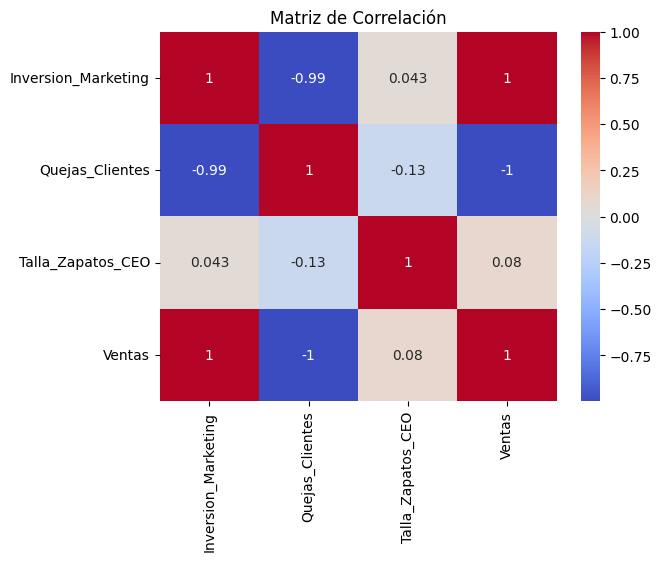

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

datos = {
    'Inversion_Marketing': [1000, 2000, 3000, 4000],  # Sube a la vez que las ventas (Positiva)
    'Quejas_Clientes': [50, 40, 20, 5],               # Baja cuando suben las ventas (Negativa)
    'Talla_Zapatos_CEO': [42, 38, 45, 40],            # Ruido absoluto
    'Ventas': [150, 280, 450, 600]                    # Nuestro objetivo a predecir
}
df = pd.DataFrame(datos)

#Crear la matriz de correlacion
matriz_correlacion = df.corr()
matriz_correlacion

sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()
